Notebook to compute INTs based on resting state stimulation data.

Workflow:
- Compute INT in each node of the brain model
- Match node INT to brain region 
- Print summary statistics of INT per brain region
- Compare INT in unimodal / transmodal topography (core / periphery)

**Step 1: Load Model Weights and Samples**

In [2]:
# Imports
import numpy as np
from hbnm.io import Data
from hbnm.bnm import Bnm

In [4]:
# Define data object

input_dir = '/home/frank/HBNM/data/'
output_dir = '/home/frank/HBNM/outputs/'
data = Data(input_dir, output_dir)
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() 


In [ ]:
# Load heterogeneous fitted model parameters
# model_path = 'Heterogeneous_Dem_Range/iteration_53.hdf5'
model_path = 'Heterogeneous_Old_Range/iteration_35.hdf5'

fin_heterogeneous = data.load(model_path, from_output=True)
print(fin_heterogeneous.keys())
theta_heterogeneous = fin_heterogeneous['theta'][:]
weights_heterogeneous = fin_heterogeneous['weights'][:]
fin_heterogeneous.close()

**Step 2: Compute BMA**

In [ ]:
# Define function to compute Bayesian Model Average

def compute_bayesian_average(theta_samples, weights):
    """Compute Bayesian Model Average from samples and weights."""
    normalized_weights = weights / np.sum(weights)
    theta_bma = np.sum(theta_samples * normalized_weights[np.newaxis, :], axis=1)
    return theta_bma

theta_bma = compute_bayesian_average(theta_heterogeneous, weights_heterogeneous)

In [ ]:
print(
    "Bayesian Model Average (theta_bma) parameters:\n"
    f"  w_EI_bias:  {theta_bma[0]:.6f}\n"
    f"  w_EI_coef:  {theta_bma[1]:.6f}\n"
    f"  w_EE_bias:  {theta_bma[2]:.6f}\n"
    f"  w_EE_coef:  {theta_bma[3]:.6f}\n"
    f"  G:          {theta_bma[4]:.6f}"
)


In [29]:
data = Data(input_dir, output_dir)
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() 

fin = data.load('demirtas_neuron_2019.hdf5', from_output=False)
theta_heterogeneous = fin['apprx_posterior_heterogeneous'][:]
theta_homogeneous = fin['apprx_posterior_homogeneous'][:]
fin.close()

"""
Set model samples
"""
heterogeneous = Bnm(sc, gradient=hmap)
heterogeneous.set('w_EI', (theta_heterogeneous[0,1], theta_heterogeneous[1,1]))
heterogeneous.set('w_EE', (theta_heterogeneous[2,1], theta_heterogeneous[3,1]))
heterogeneous.set('G', theta_heterogeneous[4,1])


**Find the Fixed Point Under Your Fitted Parameters**

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from hbnm.bnm import Bnm
from hbnm.io import Data
from scipy.linalg import eig
import pandas as pd

def find_fixed_point(model):
    """
    Find the fixed point of the fitted model.
    
    The fixed point is already computed during model initialization
    and stored in the model's steady-state variables.
    """
    
    # Ensure the model parameters are set and Jacobian is computed
    model.dmf.set_jacobian(compute_fic=True)
    
    # Extract fixed point values
    S_E_fixed = model.dmf._S_E_ss  # Excitatory synaptic gating variables
    S_I_fixed = model.dmf._S_I_ss  # Inhibitory synaptic gating variables
    
    # Also get the corresponding firing rates and currents at fixed point
    r_E_fixed = model.dmf._r_E_ss  # Excitatory firing rates
    r_I_fixed = model.dmf._r_I_ss  # Inhibitory firing rates
    I_E_fixed = model.dmf._I_E_ss  # Excitatory currents
    I_I_fixed = model.dmf._I_I_ss  # Inhibitory currents
    
    print("=== FIXED POINT ANALYSIS ===")
    print(f"Number of regions: {len(S_E_fixed)}")
    print(f"S_E fixed point range: [{S_E_fixed.min():.4f}, {S_E_fixed.max():.4f}]")
    print(f"S_I fixed point range: [{S_I_fixed.min():.4f}, {S_I_fixed.max():.4f}]")
    print(f"Excitatory firing rate range: [{r_E_fixed.min():.2f}, {r_E_fixed.max():.2f}] Hz")
    print(f"Inhibitory firing rate range: [{r_I_fixed.min():.2f}, {r_I_fixed.max():.2f}] Hz")
    
    # Verify this is indeed a fixed point by checking derivatives
    model.dmf._S_E = S_E_fixed.copy()
    model.dmf._S_I = S_I_fixed.copy()
    model.dmf._r_E = r_E_fixed.copy()
    model.dmf._r_I = r_I_fixed.copy()
    
    dSE_dt = model.dmf._dSEdt()
    dSI_dt = model.dmf._dSIdt()
    
    print(f"\nFixed point verification:")
    print(f"Max |dS_E/dt|: {np.abs(dSE_dt).max():.2e} (should be ~0)")
    print(f"Max |dS_I/dt|: {np.abs(dSI_dt).max():.2e} (should be ~0)")
    
    return {
        'S_E': S_E_fixed,
        'S_I': S_I_fixed,
        'r_E': r_E_fixed,
        'r_I': r_I_fixed,
        'I_E': I_E_fixed,
        'I_I': I_I_fixed
    }


In [31]:
# # Create model with your fitted parameters

# heterogeneous = Bnm(sc, gradient=hmap)
# heterogeneous.set('w_EI', (theta_bma[0], theta_bma[1]))
# heterogeneous.set('w_EE', (theta_bma[2], theta_bma[3]))
# heterogeneous.set('G', theta_bma[4])
# # heterogeneous.moments_method()

# # Find the fixed point
# fixed_point = find_fixed_point(heterogeneous)

In [32]:
# Create model with your fitted parameters

# heterogeneous = Bnm(sc, gradient=hmap)
# heterogeneous.set('w_EI', (theta_heterogeneous[0,0], theta_heterogeneous[1,0]))
# heterogeneous.set('w_EE', (theta_heterogeneous[2,0], theta_heterogeneous[3,0]))
# heterogeneous.set('G', theta_heterogeneous[4,0])
# heterogeneous.moments_method()

# Find the fixed point
fixed_point = find_fixed_point(heterogeneous)

=== FIXED POINT ANALYSIS ===
Number of regions: 180
S_E fixed point range: [0.1648, 0.1648]
S_I fixed point range: [0.1474, 0.1730]
Excitatory firing rate range: [3.08, 3.08] Hz
Inhibitory firing rate range: [14.74, 17.30] Hz

Fixed point verification:
Max |dS_E/dt|: 5.95e-10 (should be ~0)
Max |dS_I/dt|: 1.78e-15 (should be ~0)


**Form the Jacobian Matrix at the Fixed Point**


=== JACOBIAN ANALYSIS (Synaptic Only) ===
Jacobian shape: (360, 360)
Number of regions: 180
Variables per region: 2

Jacobian block structure:
A_EE (E→E): (180, 180), diagonal range: [212.217, 382.949]
A_EI (I→E): (180, 180), diagonal range: [-377.968, -252.884]
A_IE (E→I): (180, 180), diagonal range: [388.252, 504.233]
A_II (I→I): (180, 180), diagonal range: [-495.697, -460.322]


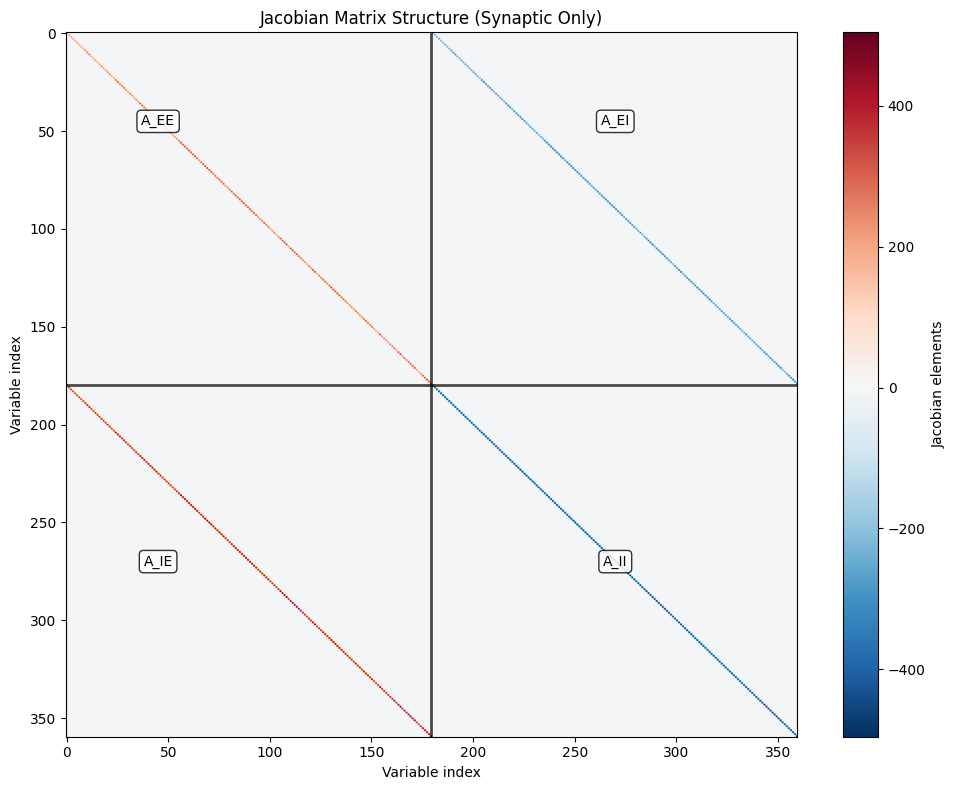

In [33]:
def analyze_jacobian(model, include_bold=False):
    """
    Extract and analyze the Jacobian matrix of the system.
    
    Parameters:
    -----------
    model : Bnm
        Your fitted brain network model
    include_bold : bool
        If True, analyze the full system including hemodynamics
    """
    
    # Ensure Jacobian is computed
    model.dmf.set_jacobian(compute_fic=True)
    
    if include_bold:
        # Compute extended Jacobian including hemodynamics
        model.dmf.moments_method(bold=True)
        J = model.dmf._jacobian_bold
        system_name = "Synaptic + Hemodynamic"
        n_vars_per_region = 6  # S_E, S_I, x, f, v, q
    else:
        # Synaptic-only Jacobian
        J = model.dmf._jacobian
        system_name = "Synaptic Only"
        n_vars_per_region = 2  # S_E, S_I
    
    n_regions = model.dmf._nc
    
    print(f"\n=== JACOBIAN ANALYSIS ({system_name}) ===")
    print(f"Jacobian shape: {J.shape}")
    print(f"Number of regions: {n_regions}")
    print(f"Variables per region: {n_vars_per_region}")
    
    # For synaptic-only system, show the block structure
    if not include_bold:
        # Extract blocks
        A_EE = J[:n_regions, :n_regions]
        A_EI = J[:n_regions, n_regions:]
        A_IE = J[n_regions:, :n_regions] 
        A_II = J[n_regions:, n_regions:]
        
        print(f"\nJacobian block structure:")
        print(f"A_EE (E→E): {A_EE.shape}, diagonal range: [{np.diag(A_EE).min():.3f}, {np.diag(A_EE).max():.3f}]")
        print(f"A_EI (I→E): {A_EI.shape}, diagonal range: [{np.diag(A_EI).min():.3f}, {np.diag(A_EI).max():.3f}]")
        print(f"A_IE (E→I): {A_IE.shape}, diagonal range: [{np.diag(A_IE).min():.3f}, {np.diag(A_IE).max():.3f}]")
        print(f"A_II (I→I): {A_II.shape}, diagonal range: [{np.diag(A_II).min():.3f}, {np.diag(A_II).max():.3f}]")
    
    # Visualize the Jacobian structure
    plt.figure(figsize=(10, 8))
    plt.imshow(J, cmap='RdBu_r', aspect='auto')
    plt.colorbar(label='Jacobian elements')
    plt.title(f'Jacobian Matrix Structure ({system_name})')
    plt.xlabel('Variable index')
    plt.ylabel('Variable index')
    
    if not include_bold:
        # Add lines to show block structure
        plt.axhline(n_regions-0.5, color='black', linewidth=2, alpha=0.7)
        plt.axvline(n_regions-0.5, color='black', linewidth=2, alpha=0.7)
        plt.text(n_regions/4, n_regions/4, 'A_EE', ha='center', va='center', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        plt.text(3*n_regions/2, n_regions/4, 'A_EI', ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        plt.text(n_regions/4, 3*n_regions/2, 'A_IE', ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        plt.text(3*n_regions/2, 3*n_regions/2, 'A_II', ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return J

# Analyze both synaptic-only and full system
J_syn = analyze_jacobian(heterogeneous, include_bold=False)
# J_full = analyze_jacobian(heterogeneous, include_bold=True)


=== STABILITY ANALYSIS (Synaptic Only) ===
Number of eigenvalues: 360
Leading eigenvalue: -0.058838 + 0.000000i
System is STABLE
Stability margin: 0.058838
Bifurcation type: Real (Transcritical/Pitchfork)
→ Approaching a steady-state bifurcation

Eigenvalue statistics:
Real parts - Min: -246.1507, Max: -0.0588
Imaginary parts - Range: [0.0000, 0.0000]
Number with Re(λ) < 0: 360
Number with Re(λ) ≥ 0: 0


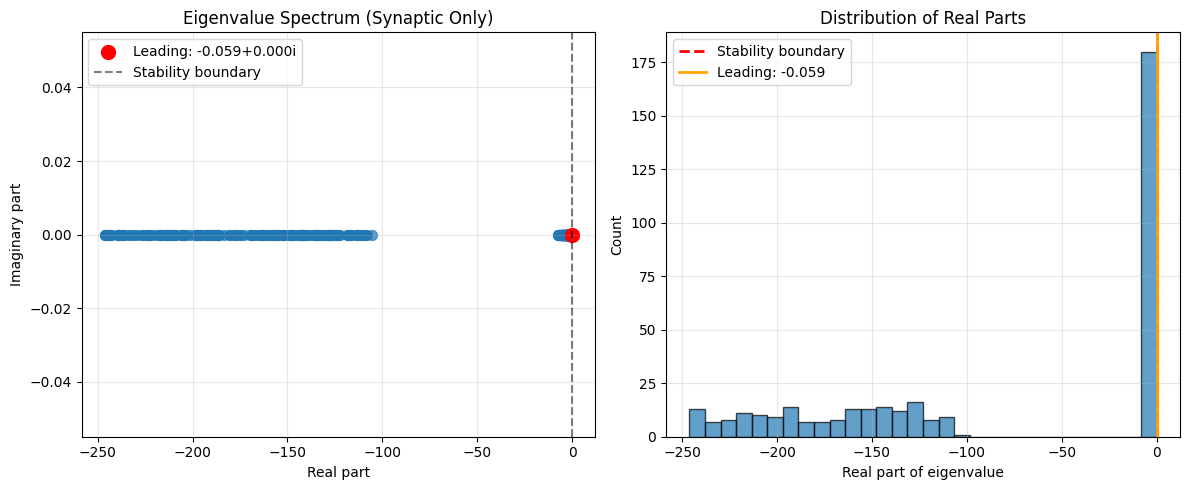

In [34]:
def stability_analysis(model, include_bold=False):
    """
    Perform comprehensive stability analysis and bifurcation classification.
    """
    
    # Get Jacobian and eigenvalues
    if include_bold:
        model.dmf.moments_method(bold=True)
        J = model.dmf._jacobian_bold
        eigenvals = model.dmf.evals_bold
        eigenvects = model.dmf.evects_bold
        system_name = "Synaptic + Hemodynamic"
    else:
        model.dmf.set_jacobian(compute_fic=True)
        J = model.dmf._jacobian
        eigenvals = model.dmf._evals
        eigenvects = model.dmf._evects
        system_name = "Synaptic Only"
    
    print(f"\n=== STABILITY ANALYSIS ({system_name}) ===")
    
    # Extract real and imaginary parts
    real_parts = np.real(eigenvals)
    imag_parts = np.imag(eigenvals)
    
    # Find leading eigenvalue (largest real part)
    leading_idx = np.argmax(real_parts)
    leading_eigenval = eigenvals[leading_idx]
    leading_real = real_parts[leading_idx]
    leading_imag = imag_parts[leading_idx]
    
    # Stability check
    is_stable = leading_real < 0
    stability_margin = -leading_real  # How far from instability
    
    print(f"Number of eigenvalues: {len(eigenvals)}")
    print(f"Leading eigenvalue: {leading_real:.6f} + {leading_imag:.6f}i")
    print(f"System is {'STABLE' if is_stable else 'UNSTABLE'}")
    print(f"Stability margin: {stability_margin:.6f}")
    
    # Classify bifurcation type
    if abs(leading_imag) < 1e-10:  # Essentially real
        bifurcation_type = "Real (Transcritical/Pitchfork)"
        print(f"Bifurcation type: {bifurcation_type}")
        print("→ Approaching a steady-state bifurcation")
    else:
        bifurcation_type = "Complex (Hopf)"
        oscillation_freq = abs(leading_imag) / (2 * np.pi)
        print(f"Bifurcation type: {bifurcation_type}")
        print(f"→ Approaching oscillatory instability")
        print(f"Critical frequency: {oscillation_freq:.4f} Hz")
    
    # Statistics of all eigenvalues
    print(f"\nEigenvalue statistics:")
    print(f"Real parts - Min: {real_parts.min():.4f}, Max: {real_parts.max():.4f}")
    print(f"Imaginary parts - Range: [{imag_parts.min():.4f}, {imag_parts.max():.4f}]")
    print(f"Number with Re(λ) < 0: {np.sum(real_parts < 0)}")
    print(f"Number with Re(λ) ≥ 0: {np.sum(real_parts >= 0)}")
    
    # Plot eigenvalue spectrum
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(real_parts, imag_parts, alpha=0.7, s=50)
    plt.scatter(leading_real, leading_imag, color='red', s=100, 
                label=f'Leading: {leading_real:.3f}+{leading_imag:.3f}i')
    plt.axvline(0, color='black', linestyle='--', alpha=0.5, label='Stability boundary')
    plt.xlabel('Real part')
    plt.ylabel('Imaginary part')
    plt.title(f'Eigenvalue Spectrum ({system_name})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(real_parts, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Stability boundary')
    plt.axvline(leading_real, color='orange', linewidth=2, label=f'Leading: {leading_real:.3f}')
    plt.xlabel('Real part of eigenvalue')
    plt.ylabel('Count')
    plt.title('Distribution of Real Parts')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'eigenvalues': eigenvals,
        'eigenvectors': eigenvects,
        'leading_eigenvalue': leading_eigenval,
        'is_stable': is_stable,
        'stability_margin': stability_margin,
        'bifurcation_type': bifurcation_type,
        'leading_frequency': abs(leading_imag) / (2 * np.pi) if abs(leading_imag) > 1e-10 else 0
    }

# Perform stability analysis
stability_syn = stability_analysis(heterogeneous, include_bold=False)
# stability_full = stability_analysis(model, include_bold=True)


=== MODE TIMESCALES (Synaptic Only) ===
Number of stable modes: 360
Timescale range: [0.0041, 16.9958] seconds

Slowest 5 modes:
  Mode 1: τ = 16.9958s, λ = -0.0588+0.0000i, f = 0.000Hz (Exponential)
  Mode 2: τ = 7.2272s, λ = -0.1384+0.0000i, f = 0.000Hz (Exponential)
  Mode 3: τ = 5.5290s, λ = -0.1809+0.0000i, f = 0.000Hz (Exponential)
  Mode 4: τ = 3.8172s, λ = -0.2620+0.0000i, f = 0.000Hz (Exponential)
  Mode 5: τ = 2.8638s, λ = -0.3492+0.0000i, f = 0.000Hz (Exponential)

Fastest 5 modes:
  Mode 5: τ = 0.0041s, λ = -245.2479+0.0000i, f = 0.000Hz (Exponential)
  Mode 4: τ = 0.0041s, λ = -245.5139+0.0000i, f = 0.000Hz (Exponential)
  Mode 3: τ = 0.0041s, λ = -246.0353+0.0000i, f = 0.000Hz (Exponential)
  Mode 2: τ = 0.0041s, λ = -246.0911+0.0000i, f = 0.000Hz (Exponential)
  Mode 1: τ = 0.0041s, λ = -246.1507+0.0000i, f = 0.000Hz (Exponential)


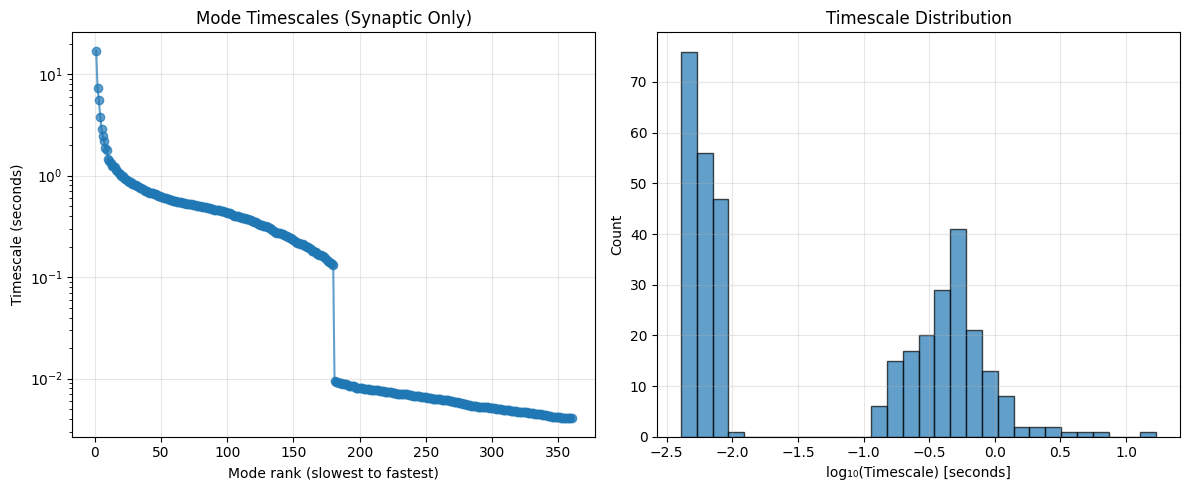

In [35]:
def calculate_mode_timescales(stability_results, system_name=""):
    """
    Calculate timescales for each dynamical mode.
    """
    
    eigenvals = stability_results['eigenvalues']
    real_parts = np.real(eigenvals)
    imag_parts = np.imag(eigenvals)
    
    print(f"\n=== MODE TIMESCALES ({system_name}) ===")
    
    # Calculate timescales (only for stable modes)
    stable_mask = real_parts < 0
    stable_eigenvals = eigenvals[stable_mask]
    stable_reals = real_parts[stable_mask]
    
    if len(stable_reals) == 0:
        print("No stable modes found!")
        return None
    
    # Timescales in seconds
    timescales = -1.0 / stable_reals
    
    # Sort by timescale (slowest first)
    sorted_indices = np.argsort(timescales)[::-1]
    timescales_sorted = timescales[sorted_indices]
    eigenvals_sorted = stable_eigenvals[sorted_indices]
    
    print(f"Number of stable modes: {len(timescales)}")
    print(f"Timescale range: [{timescales.min():.4f}, {timescales.max():.4f}] seconds")
    
    # Show slowest and fastest modes
    print(f"\nSlowest 5 modes:")
    for i in range(min(5, len(timescales_sorted))):
        eig_val = eigenvals_sorted[i]
        tau = timescales_sorted[i]
        freq = abs(np.imag(eig_val)) / (2 * np.pi)
        mode_type = "Oscillatory" if freq > 0.01 else "Exponential"
        print(f"  Mode {i+1}: τ = {tau:.4f}s, λ = {np.real(eig_val):.4f}+{np.imag(eig_val):.4f}i, "
              f"f = {freq:.3f}Hz ({mode_type})")
    
    print(f"\nFastest 5 modes:")
    for i in range(max(0, len(timescales_sorted)-5), len(timescales_sorted)):
        eig_val = eigenvals_sorted[i]
        tau = timescales_sorted[i]
        freq = abs(np.imag(eig_val)) / (2 * np.pi)
        mode_type = "Oscillatory" if freq > 0.01 else "Exponential"
        print(f"  Mode {len(timescales_sorted)-i}: τ = {tau:.4f}s, λ = {np.real(eig_val):.4f}+{np.imag(eig_val):.4f}i, "
              f"f = {freq:.3f}Hz ({mode_type})")
    
    # Plot timescale distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.semilogy(range(1, len(timescales_sorted)+1), timescales_sorted, 'o-', alpha=0.7)
    plt.xlabel('Mode rank (slowest to fastest)')
    plt.ylabel('Timescale (seconds)')
    plt.title(f'Mode Timescales ({system_name})')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(np.log10(timescales), bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('log₁₀(Timescale) [seconds]')
    plt.ylabel('Count')
    plt.title('Timescale Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'timescales': timescales,
        'timescales_sorted': timescales_sorted,
        'eigenvalues_sorted': eigenvals_sorted,
        'stable_mask': stable_mask
    }

# Calculate timescales for both systems
timescales_syn = calculate_mode_timescales(stability_syn, "Synaptic Only")
# timescales_full = calculate_mode_timescales(stability_full, "Synaptic + Hemodynamic")


=== REGIONAL TIMESCALE MAPPING (Synaptic Only) ===
Analyzing Excitatory (S_E) components
Regional eigenvector shape: (180, 360)
Regional timescale range: [0.0928, 1.3570] seconds
Mean regional timescale: 0.4693 seconds

Slowest region: 79 (τ = 1.3570s)
Fastest region: 179 (τ = 0.0928s)
Correlation with node strength: 0.091


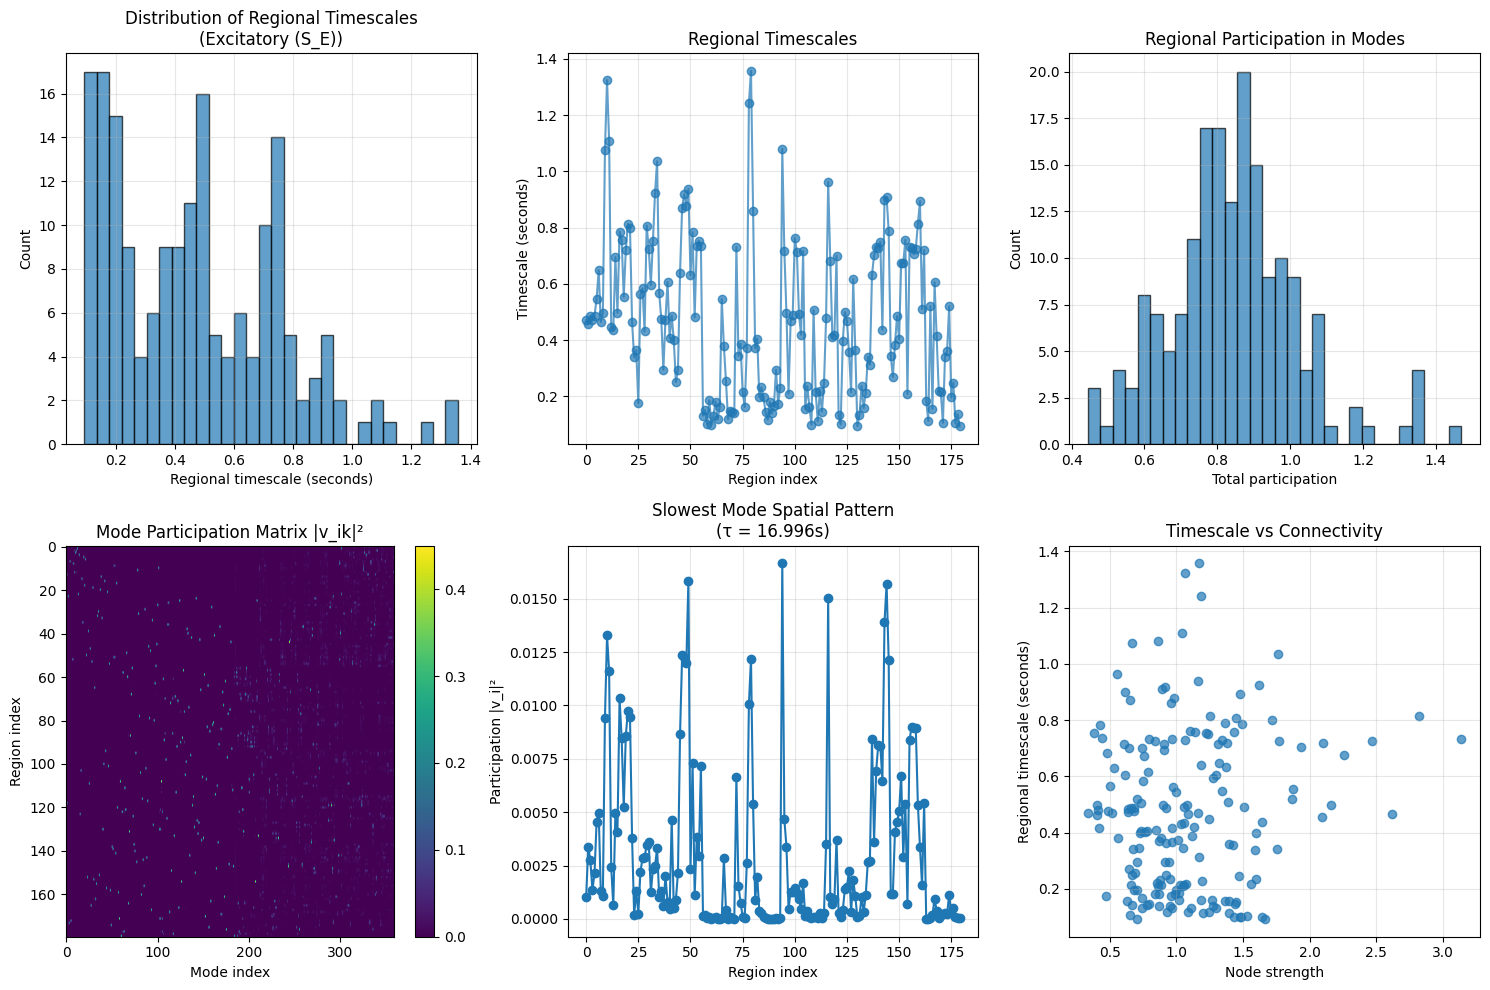

In [36]:
def map_timescales_to_regions(model, stability_results, timescale_results, 
                              include_bold=False, focus_on_excitatory=True):
    """
    Map mode timescales to individual brain regions based on eigenvector participation.
    """
    
    if timescale_results is None:
        print("No stable modes to analyze!")
        return None
    
    n_regions = model.dmf._nc
    eigenvals = stability_results['eigenvalues']
    eigenvects = stability_results['eigenvectors']
    
    # Get stable modes
    stable_mask = timescale_results['stable_mask']
    stable_timescales = timescale_results['timescales']
    stable_eigenvects = eigenvects[:, stable_mask]
    
    system_name = "Synaptic + Hemodynamic" if include_bold else "Synaptic Only"
    print(f"\n=== REGIONAL TIMESCALE MAPPING ({system_name}) ===")
    
    if include_bold:
        # For full system: extract excitatory components (first n_regions entries of each eigenvector)
        if focus_on_excitatory:
            regional_eigenvects = stable_eigenvects[:n_regions, :]  # S_E components
            var_name = "Excitatory (S_E)"
        else:
            # Could also analyze hemodynamic variables
            regional_eigenvects = stable_eigenvects[4*n_regions:5*n_regions, :]  # BOLD (v) components
            var_name = "BOLD (v)"
    else:
        # For synaptic system: extract excitatory components
        if focus_on_excitatory:
            regional_eigenvects = stable_eigenvects[:n_regions, :]  # S_E components
            var_name = "Excitatory (S_E)"
        else:
            regional_eigenvects = stable_eigenvects[n_regions:, :]  # S_I components  
            var_name = "Inhibitory (S_I)"
    
    print(f"Analyzing {var_name} components")
    print(f"Regional eigenvector shape: {regional_eigenvects.shape}")
    
    # Calculate participation weights |v_ik|^2
    participation_weights = np.abs(regional_eigenvects)**2
    
    # Calculate regional timescales
    regional_timescales = np.zeros(n_regions)
    regional_participations = np.zeros(n_regions)
    
    for i in range(n_regions):
        weights_i = participation_weights[i, :]
        total_participation = np.sum(weights_i)
        
        if total_participation > 1e-12:  # Avoid division by zero
            regional_timescales[i] = np.sum(weights_i * stable_timescales) / total_participation
            regional_participations[i] = total_participation
        else:
            regional_timescales[i] = np.nan
            regional_participations[i] = 0
    
    print(f"Regional timescale range: [{np.nanmin(regional_timescales):.4f}, {np.nanmax(regional_timescales):.4f}] seconds")
    print(f"Mean regional timescale: {np.nanmean(regional_timescales):.4f} seconds")
    
    # Find regions with extreme timescales
    valid_mask = ~np.isnan(regional_timescales)
    if np.sum(valid_mask) > 0:
        slowest_region = np.argmax(regional_timescales[valid_mask])
        fastest_region = np.argmin(regional_timescales[valid_mask])
        
        print(f"\nSlowest region: {np.where(valid_mask)[0][slowest_region]} "
              f"(τ = {regional_timescales[valid_mask][slowest_region]:.4f}s)")
        print(f"Fastest region: {np.where(valid_mask)[0][fastest_region]} "
              f"(τ = {regional_timescales[valid_mask][fastest_region]:.4f}s)")
    
    # Analyze relationship with structural properties
    if hasattr(model.dmf, '_SC'):
        # Node strength (total connectivity)
        node_strength = np.sum(model.dmf._SC, axis=1)
        
        # Correlation with structural connectivity
        valid_indices = valid_mask & (node_strength > 0)
        if np.sum(valid_indices) > 5:
            correlation = np.corrcoef(regional_timescales[valid_indices], 
                                    node_strength[valid_indices])[0, 1]
            print(f"Correlation with node strength: {correlation:.3f}")
    
    # Visualization
    plt.figure(figsize=(15, 10))
    
    # Regional timescales
    plt.subplot(2, 3, 1)
    valid_timescales = regional_timescales[valid_mask]
    plt.hist(valid_timescales, bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('Regional timescale (seconds)')
    plt.ylabel('Count')
    plt.title(f'Distribution of Regional Timescales\n({var_name})')
    plt.grid(True, alpha=0.3)
    
    # Regional timescales vs region index
    plt.subplot(2, 3, 2)
    plt.plot(range(n_regions), regional_timescales, 'o-', alpha=0.7)
    plt.xlabel('Region index')
    plt.ylabel('Timescale (seconds)')
    plt.title('Regional Timescales')
    plt.grid(True, alpha=0.3)
    
    # Participation in modes
    plt.subplot(2, 3, 3)
    plt.hist(regional_participations[valid_mask], bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('Total participation')
    plt.ylabel('Count')
    plt.title('Regional Participation in Modes')
    plt.grid(True, alpha=0.3)
    
    # Mode participation matrix
    plt.subplot(2, 3, 4)
    plt.imshow(participation_weights, aspect='auto', cmap='viridis')
    plt.xlabel('Mode index')
    plt.ylabel('Region index')
    plt.title('Mode Participation Matrix |v_ik|²')
    plt.colorbar()
    
    # Slowest mode spatial pattern
    slowest_mode_idx = np.argmax(stable_timescales)
    plt.subplot(2, 3, 5)
    plt.plot(range(n_regions), participation_weights[:, slowest_mode_idx], 'o-')
    plt.xlabel('Region index')
    plt.ylabel('Participation |v_i|²')
    plt.title(f'Slowest Mode Spatial Pattern\n(τ = {stable_timescales[slowest_mode_idx]:.3f}s)')
    plt.grid(True, alpha=0.3)
    
    # Timescale vs node strength (if available)
    plt.subplot(2, 3, 6)
    if hasattr(model.dmf, '_SC'):
        valid_for_corr = valid_mask & (node_strength > 0)
        if np.sum(valid_for_corr) > 0:
            plt.scatter(node_strength[valid_for_corr], regional_timescales[valid_for_corr], alpha=0.7)
            plt.xlabel('Node strength')
            plt.ylabel('Regional timescale (seconds)')
            plt.title('Timescale vs Connectivity')
            plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'regional_timescales': regional_timescales,
        'participation_weights': participation_weights,
        'regional_participations': regional_participations,
        'valid_mask': valid_mask
    }

# Map timescales to regions for both systems
regional_syn = map_timescales_to_regions(heterogeneous, stability_syn, timescales_syn, 
                                        include_bold=False, focus_on_excitatory=True)

In [37]:
regional_syn.keys()

dict_keys(['regional_timescales', 'participation_weights', 'regional_participations', 'valid_mask'])

In [38]:
valid_timescales = regional_syn['regional_timescales'][regional_syn['valid_mask']]

In [39]:
print("Summary statistics for valid_timescales:")
print(f"  min:   {np.min(valid_timescales):.4f}")
print(f"  max:   {np.max(valid_timescales):.4f}")
print(f"  mean:  {np.mean(valid_timescales):.4f}")
print(f"  std:   {np.std(valid_timescales):.4f}")
print(f"  range: {np.ptp(valid_timescales):.4f}")

Summary statistics for valid_timescales:
  min:   0.0928
  max:   1.3570
  mean:  0.4693
  std:   0.2793
  range: 1.2642


In [40]:
import pandas as pd

# Load the parcellation file
parcellation_path = "/home/frank/HBNM/data/parcellation_df_L.csv"
parcellation_df = pd.read_csv(parcellation_path)

# Check how many regions are in the parcellation
print(f"Number of regions in parcellation: {len(parcellation_df)}")

# Check shape of valid_timescales
print(f"Number of valid timescales: {len(valid_timescales)}")

# If valid_timescales is less than 180, we need to map them appropriately.
# Let's assume valid_mask is the mask for the 180 regions in the parcellation.
# We'll create a new column in the parcellation dataframe for timescales.

# If regional_syn['regional_timescales'] is length 180, map using valid_mask
if len(regional_syn['regional_timescales']) == len(parcellation_df):
    parcellation_df['timescale'] = pd.NA
    parcellation_df.loc[regional_syn['valid_mask'], 'timescale'] = regional_syn['regional_timescales'][regional_syn['valid_mask']]
    print("Mapped timescales to parcellation dataframe using valid_mask.")
else:
    # If not, just assign valid_timescales to the first N valid rows
    parcellation_df['timescale'] = pd.NA
    valid_indices = parcellation_df.index[regional_syn['valid_mask']]
    if len(valid_indices) == len(valid_timescales):
        parcellation_df.loc[valid_indices, 'timescale'] = valid_timescales
        print("Mapped valid_timescales to valid regions in parcellation dataframe.")
    else:
        print("Warning: Number of valid_timescales does not match number of valid regions in parcellation.")

# Show a preview
parcellation_df.head()


Number of regions in parcellation: 180
Number of valid timescales: 180
Mapped timescales to parcellation dataframe using valid_mask.


,Parcel,Hemisphere,AreaAbbreviation,AreaName,SectionNumber,Region,NetworkID,NetworkName,NetworkRGB,NetworkRGBA,timescale
0,1,L,V1,Primary Visual Cortex,1,Primary_Visual,1,Visual1,"[0, 0, 255]","[0, 0, 255, 255]",0.470883
1,2,L,MST,Medial Superior\nTemporal Area,5,MT+_Complex_and_Neighboring_Visual_Areas,2,Visual2,"[100, 0, 255]","[100, 0, 255, 255]",0.455853
2,3,L,V6,Sixth Visual Area,3,Dorsal_Stream_Visual,2,Visual2,"[100, 0, 255]","[100, 0, 255, 255]",0.486295
3,4,L,V2,Second Visual Area,2,Early_Visual,2,Visual2,"[100, 0, 255]","[100, 0, 255, 255]",0.469713
4,5,L,V3,Third Visual Area,2,Early_Visual,2,Visual2,"[100, 0, 255]","[100, 0, 255, 255]",0.487151


In [41]:
# Compute summary statistics of timescales for each network

# Ensure 'NetworkName' and 'timescale' columns exist
if 'NetworkName' in parcellation_df.columns and 'timescale' in parcellation_df.columns:
    # Drop rows with missing timescales
    timescale_stats = (
        parcellation_df.dropna(subset=['timescale'])
        .groupby('NetworkName')['timescale']
        .agg(['count', 'min', 'max', 'mean', 'std', 'median'])
        .sort_values('mean', ascending=True)
    )
    print("Summary statistics of timescales for each network (ordered by mean, low to high):")
    display(timescale_stats)
else:
    print("Required columns 'NetworkName' and/or 'timescale' not found in parcellation_df.")


Summary statistics of timescales for each network (ordered by mean, low to high):


,count,min,max,mean,std,median
NetworkName,,,,,,
Ventral-Multimodal,2,0.133328,0.212866,0.173097,0.056242,0.173097
Cingulo-Opercular,27,0.092755,1.075699,0.281502,0.216807,0.197302
Default,40,0.094169,1.035311,0.351548,0.266408,0.222115
Orbito-Affective,3,0.112268,0.520428,0.379599,0.231626,0.506102
Auditory,8,0.236236,0.519773,0.387872,0.090717,0.378922
Frontoparietal,22,0.161896,1.357004,0.428254,0.310599,0.332173
Language,14,0.099768,1.242498,0.521492,0.357762,0.443037
Somatomotor,19,0.246463,0.871129,0.595026,0.158902,0.605297
Visual1,3,0.470883,0.749972,0.640131,0.148726,0.699538


In [42]:
# =================================================================
# DEBUGGING THE INVERTED HIERARCHY PATTERN
# =================================================================

print("=== DEBUGGING INVERTED TIMESCALE HIERARCHY ===")

# Issue 1: CHECK MAP INVERSION
print("\n1. CHECKING HETEROGENEITY MAP ORIENTATION")
print("-" * 50)

# Load parcellation to identify sensory vs association regions
parcellation_path = "/home/frank/HBNM/data/parcellation_df_L.csv"
parcellation_df = pd.read_csv(parcellation_path)

# Define sensory vs association networks
sensory_networks = ['Visual1', 'Visual2', 'Somatomotor', 'Auditory'] 
association_networks = ['Default', 'Frontoparietal', 'Cingulo-Opercular', 'Language']

# Get region indices for each type
sensory_indices = parcellation_df[parcellation_df['NetworkName'].isin(sensory_networks)].index.values
association_indices = parcellation_df[parcellation_df['NetworkName'].isin(association_networks)].index.values

print(f"Sensory regions: {len(sensory_indices)} regions")
print(f"Association regions: {len(association_indices)} regions")

# Check w_EE and w_EI values in sensory vs association
w_EE_sensory = heterogeneous.dmf._w_EE[sensory_indices].mean()
w_EE_association = heterogeneous.dmf._w_EE[association_indices].mean()
w_EI_sensory = heterogeneous.dmf._w_EI[sensory_indices].mean()
w_EI_association = heterogeneous.dmf._w_EI[association_indices].mean()

print(f"\nParameter values:")
print(f"w_EE sensory:     {w_EE_sensory:.4f}")
print(f"w_EE association: {w_EE_association:.4f}")
print(f"w_EI sensory:     {w_EI_sensory:.4f}")
print(f"w_EI association: {w_EI_association:.4f}")

print(f"\nExpected in Demirtaş:")
print(f"Association should have HIGHER w_EE (more recurrence → longer timescales)")
print(f"Association should have LOWER w_EI (less inhibition → longer timescales)")

print(f"\nYour results:")
print(f"w_EE: Association {'>' if w_EE_association > w_EE_sensory else '<'} Sensory ({'CORRECT' if w_EE_association > w_EE_sensory else 'WRONG'})")
print(f"w_EI: Association {'<' if w_EI_association < w_EI_sensory else '>'} Sensory ({'CORRECT' if w_EI_association < w_EI_sensory else 'WRONG'})")

# Check heterogeneity map correlation
hmap_sensory = hmap[sensory_indices].mean()
hmap_association = hmap[association_indices].mean()
print(f"\nHeterogeneity map values:")
print(f"hmap sensory:     {hmap_sensory:.4f}")
print(f"hmap association: {hmap_association:.4f}")
print(f"Map direction: Association {'>' if hmap_association > hmap_sensory else '<'} Sensory")

# Issue 2: CHECK EIGENVALUE SELECTION
print("\n2. CHECKING EIGENVALUE SELECTION")
print("-" * 50)

eigenvals = stability_syn['eigenvalues']
real_parts = np.real(eigenvals)

# Sort eigenvalues by real part (most negative to least negative)
sorted_indices = np.argsort(real_parts)
eigenvals_by_real = eigenvals[sorted_indices]
reals_sorted = real_parts[sorted_indices]

print(f"Most negative eigenvalue: {reals_sorted[0]:.6f} (τ = {-1/reals_sorted[0]:.6f}s)")
print(f"Least negative eigenvalue: {reals_sorted[-1]:.6f} (τ = {-1/reals_sorted[-1]:.6f}s)")
print(f"Leading (closest to zero): {reals_sorted[-1]:.6f} (SLOWEST mode)")

# Check if you're using the wrong end
current_slowest_tau = timescales_syn['timescales_sorted'][0]
correct_slowest_tau = -1.0 / reals_sorted[-1]
print(f"\nCurrent slowest τ in your analysis: {current_slowest_tau:.6f}s")
print(f"Correct slowest τ (closest to zero): {correct_slowest_tau:.6f}s")
print(f"Match: {'YES' if abs(current_slowest_tau - correct_slowest_tau) < 1e-6 else 'NO'}")

# Issue 3: CHECK WEIGHTING CALCULATION
print("\n3. CHECKING EIGENVECTOR WEIGHTING")
print("-" * 50)

# Get eigenvectors and check if they're squared
eigenvects = stability_syn['eigenvectors']
stable_mask = timescales_syn['stable_mask']
stable_eigenvects = eigenvects[:, stable_mask]

# Check the participation calculation
n_regions = heterogeneous.dmf._nc
regional_eigenvects = stable_eigenvects[:n_regions, :]  # S_E components

# Show what's being used for weighting
print(f"Eigenvector shape: {regional_eigenvects.shape}")
print(f"Sample eigenvector element: {regional_eigenvects[0, 0]:.6f}")
print(f"Sample |eigenvector|²: {np.abs(regional_eigenvects[0, 0])**2:.6f}")

# Check if participation_weights are squared
participation_weights = regional_syn['participation_weights']
manual_squared = np.abs(regional_eigenvects)**2

print(f"Participation weights match |v|²: {np.allclose(participation_weights, manual_squared)}")

# Show sample calculation for first region
sample_region = 0
weights_sample = participation_weights[sample_region, :]
stable_timescales = timescales_syn['timescales']
manual_calc = np.sum(weights_sample * stable_timescales) / np.sum(weights_sample)
stored_calc = regional_syn['regional_timescales'][sample_region]

print(f"\nSample calculation for region {sample_region}:")
print(f"Manual calculation: {manual_calc:.6f}s")
print(f"Stored calculation: {stored_calc:.6f}s")
print(f"Match: {'YES' if abs(manual_calc - stored_calc) < 1e-6 else 'NO'}")

=== DEBUGGING INVERTED TIMESCALE HIERARCHY ===

1. CHECKING HETEROGENEITY MAP ORIENTATION
--------------------------------------------------
Sensory regions: 57 regions
Association regions: 103 regions

Parameter values:
w_EE sensory:     5.4316
w_EE association: 6.9325
w_EI sensory:     1.1281
w_EI association: 1.2135

Expected in Demirtaş:
Association should have HIGHER w_EE (more recurrence → longer timescales)
Association should have LOWER w_EI (less inhibition → longer timescales)

Your results:
w_EE: Association > Sensory (CORRECT)
w_EI: Association > Sensory (WRONG)

Heterogeneity map values:
hmap sensory:     0.5011
hmap association: -0.3400
Map direction: Association < Sensory

2. CHECKING EIGENVALUE SELECTION
--------------------------------------------------
Most negative eigenvalue: -246.150750 (τ = 0.004063s)
Least negative eigenvalue: -0.058838 (τ = 16.995764s)
Leading (closest to zero): -0.058838 (SLOWEST mode)

Current slowest τ in your analysis: 16.995764s
Correct slow

=== CONFIRMING MAP INVERSION ISSUE ===
Current map invert flags: [True]

Manual calculation:
w_EI_bias: 1.020065
w_EI_coef: 0.189336

Raw hmap values:
hmap sensory mean:     0.5011
hmap association mean: -0.3400

With inversion (current):
w_EI sensory:     1.0688
w_EI association: 1.1509

Without inversion (desired):
w_EI sensory:     1.1607
w_EI association: 1.0785

=== CREATING CORRECTED MODEL ===

Corrected model parameters:
w_EI sensory:     1.1607
w_EI association: 1.0785
w_EE sensory:     5.8694
w_EE association: 4.7260

Hierarchy check:
w_EE: Association < Sensory (WRONG)
w_EI: Association < Sensory (CORRECT)

=== RE-RUNNING ANALYSIS WITH CORRECTED MODEL ===

=== STABILITY ANALYSIS (Synaptic Only) ===
Number of eigenvalues: 360
Leading eigenvalue: -0.035763 + 0.000000i
System is STABLE
Stability margin: 0.035763
Bifurcation type: Real (Transcritical/Pitchfork)
→ Approaching a steady-state bifurcation

Eigenvalue statistics:
Real parts - Min: -266.3970, Max: -0.0358
Imaginary par

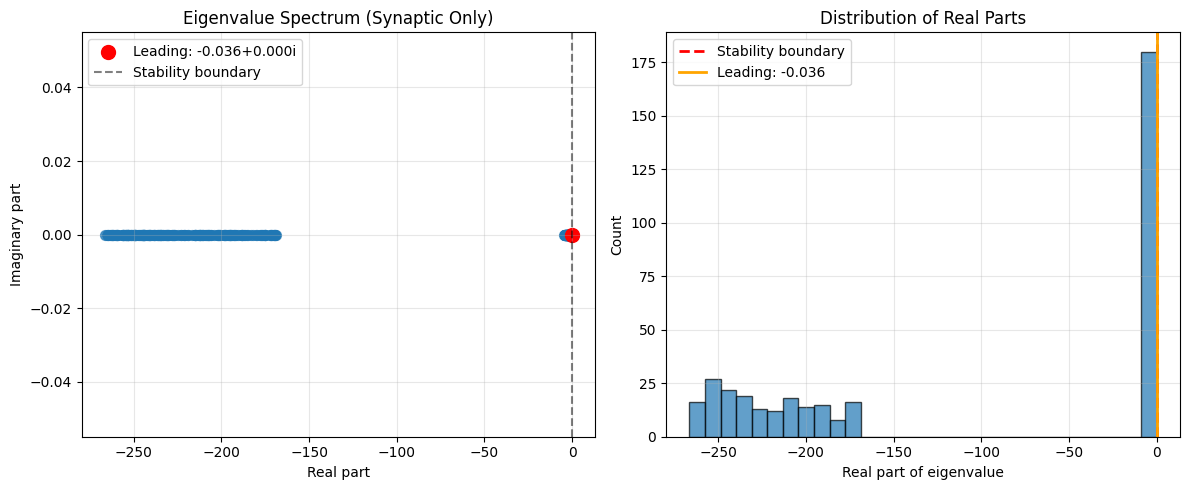


=== MODE TIMESCALES (Corrected Synaptic) ===
Number of stable modes: 360
Timescale range: [0.0038, 27.9618] seconds

Slowest 5 modes:
  Mode 1: τ = 27.9618s, λ = -0.0358+0.0000i, f = 0.000Hz (Exponential)
  Mode 2: τ = 6.7199s, λ = -0.1488+0.0000i, f = 0.000Hz (Exponential)
  Mode 3: τ = 4.8022s, λ = -0.2082+0.0000i, f = 0.000Hz (Exponential)
  Mode 4: τ = 4.1256s, λ = -0.2424+0.0000i, f = 0.000Hz (Exponential)
  Mode 5: τ = 3.8236s, λ = -0.2615+0.0000i, f = 0.000Hz (Exponential)

Fastest 5 modes:
  Mode 5: τ = 0.0038s, λ = -263.4570+0.0000i, f = 0.000Hz (Exponential)
  Mode 4: τ = 0.0038s, λ = -264.3375+0.0000i, f = 0.000Hz (Exponential)
  Mode 3: τ = 0.0038s, λ = -264.3819+0.0000i, f = 0.000Hz (Exponential)
  Mode 2: τ = 0.0038s, λ = -265.0800+0.0000i, f = 0.000Hz (Exponential)
  Mode 1: τ = 0.0038s, λ = -266.3970+0.0000i, f = 0.000Hz (Exponential)


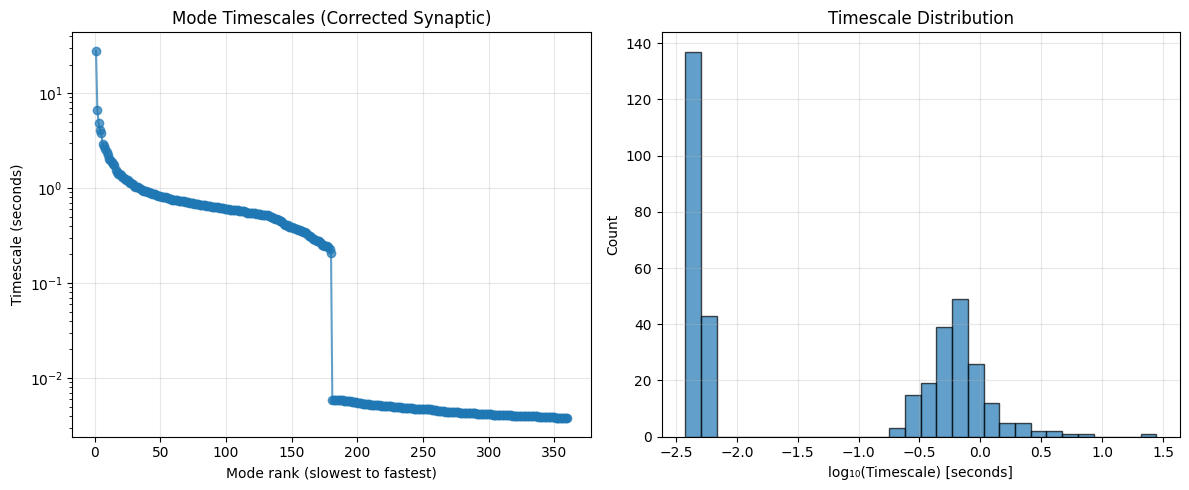


=== REGIONAL TIMESCALE MAPPING (Synaptic Only) ===
Analyzing Excitatory (S_E) components
Regional eigenvector shape: (180, 360)
Regional timescale range: [0.1768, 1.4115] seconds
Mean regional timescale: 0.6782 seconds

Slowest region: 72 (τ = 1.4115s)
Fastest region: 23 (τ = 0.1768s)
Correlation with node strength: -0.328


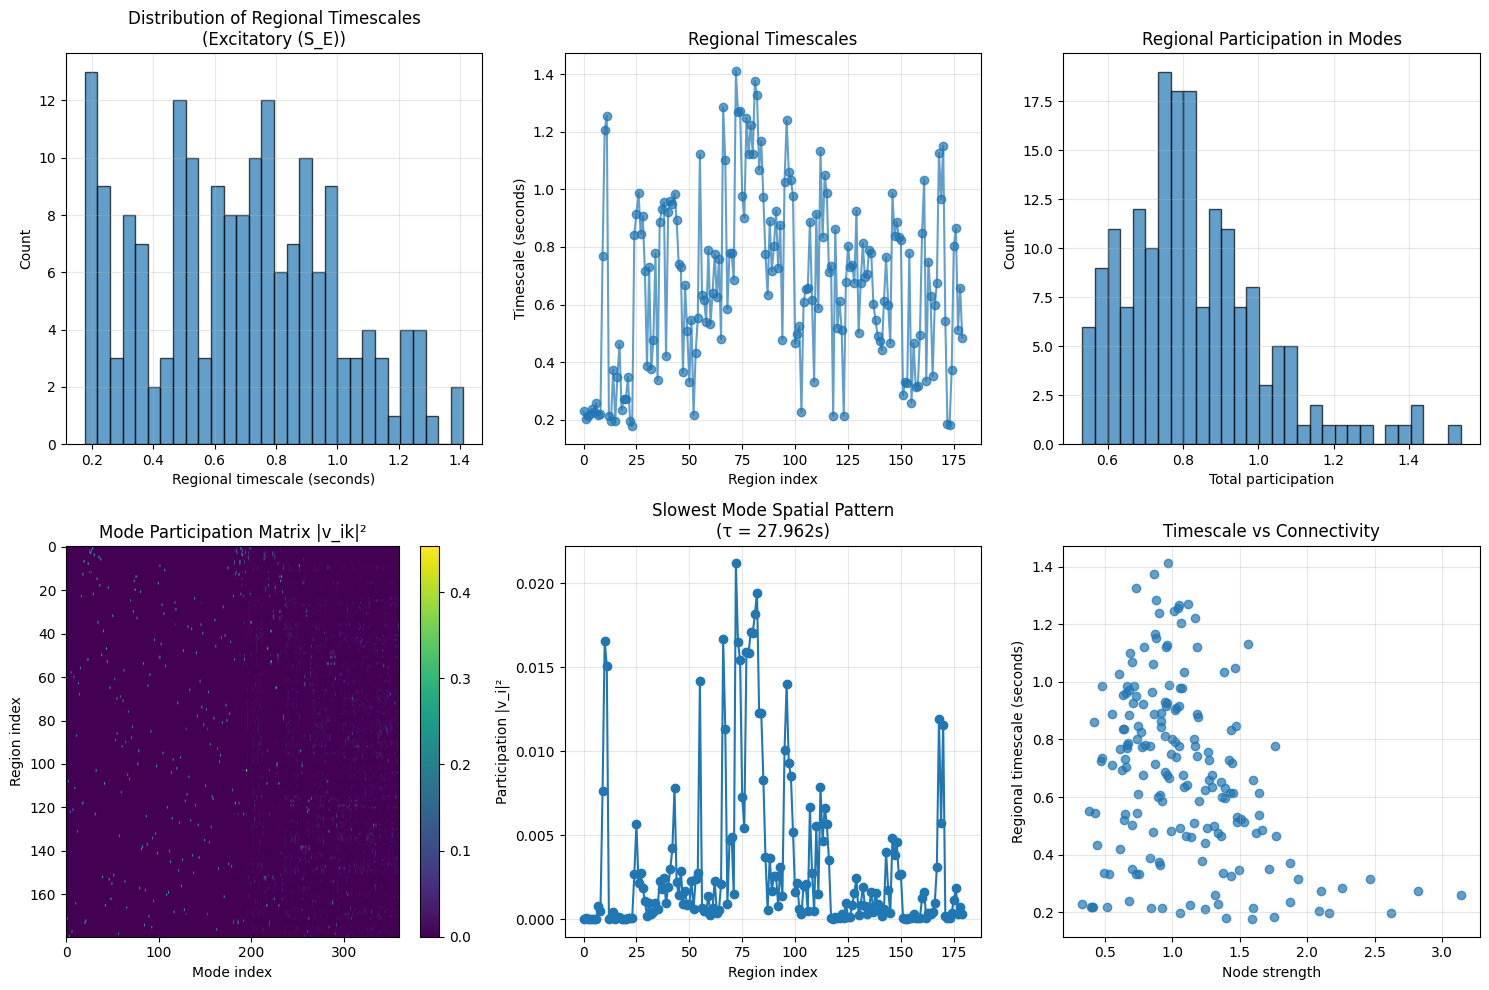


CORRECTED timescale hierarchy (ordered by mean, low to high):


,count,min,max,mean,std,median
NetworkName,,,,,,
Auditory,8,0.176775,0.658246,0.316984,0.184015,0.220113
Visual2,27,0.195950,0.666890,0.321013,0.122136,0.284996
Visual1,3,0.228873,0.520123,0.396904,0.150707,0.441716
Orbito-Affective,3,0.332745,0.587024,0.423793,0.141676,0.351611
Somatomotor,19,0.216904,1.121445,0.612235,0.304647,0.544877
Posterior-Multimodal,3,0.474413,0.988413,0.651280,0.292084,0.491014
Ventral-Multimodal,2,0.611773,0.705633,0.658703,0.066369,0.658703
Default,40,0.213875,1.284994,0.729974,0.198897,0.742442
Dorsal-attention,12,0.465717,1.206083,0.753016,0.228700,0.735628


In [43]:
# =================================================================
# CONFIRM AND FIX THE MAP INVERSION ISSUE
# =================================================================

print("=== CONFIRMING MAP INVERSION ISSUE ===")

# Check current inversion setting
print(f"Current map invert flags: {heterogeneous.dmf._map_invert_flags}")

# Manual calculation to verify the issue
w_EI_bias = theta_heterogeneous[0,0]  # 0.505506
w_EI_coef = theta_heterogeneous[1,0]  # 0.621024

print(f"\nManual calculation:")
print(f"w_EI_bias: {w_EI_bias:.6f}")
print(f"w_EI_coef: {w_EI_coef:.6f}")

# Raw map values
print(f"\nRaw hmap values:")
print(f"hmap sensory mean:     {hmap[sensory_indices].mean():.4f}")
print(f"hmap association mean: {hmap[association_indices].mean():.4f}")

# With default inversion (what's currently happening)
hmap_normalized = (hmap - hmap.min()) / (hmap.max() - hmap.min())
hmap_inverted = 1.0 - hmap_normalized  # Default inversion

w_EI_with_inversion = w_EI_bias + w_EI_coef * hmap_inverted
print(f"\nWith inversion (current):")
print(f"w_EI sensory:     {w_EI_with_inversion[sensory_indices].mean():.4f}")
print(f"w_EI association: {w_EI_with_inversion[association_indices].mean():.4f}")

# Without inversion (what we want)
w_EI_without_inversion = w_EI_bias + w_EI_coef * hmap_normalized
print(f"\nWithout inversion (desired):")
print(f"w_EI sensory:     {w_EI_without_inversion[sensory_indices].mean():.4f}")
print(f"w_EI association: {w_EI_without_inversion[association_indices].mean():.4f}")

# =================================================================
# CREATE CORRECTED MODEL
# =================================================================

print("\n=== CREATING CORRECTED MODEL ===")

# Create new model with explicit map inversion control
heterogeneous_corrected = Bnm(sc, maps=hmap, map_invert_flags=[False])  # NO inversion
heterogeneous_corrected.set('w_EI', (theta_heterogeneous[0,0], theta_heterogeneous[1,0]))
heterogeneous_corrected.set('w_EE', (theta_heterogeneous[2,0], theta_heterogeneous[3,0]))
heterogeneous_corrected.set('G', theta_heterogeneous[4,0])

# Verify the correction
print(f"\nCorrected model parameters:")
w_EI_corrected_sensory = heterogeneous_corrected.dmf._w_EI[sensory_indices].mean()
w_EI_corrected_association = heterogeneous_corrected.dmf._w_EI[association_indices].mean()
w_EE_corrected_sensory = heterogeneous_corrected.dmf._w_EE[sensory_indices].mean()
w_EE_corrected_association = heterogeneous_corrected.dmf._w_EE[association_indices].mean()

print(f"w_EI sensory:     {w_EI_corrected_sensory:.4f}")
print(f"w_EI association: {w_EI_corrected_association:.4f}")
print(f"w_EE sensory:     {w_EE_corrected_sensory:.4f}")
print(f"w_EE association: {w_EE_corrected_association:.4f}")

print(f"\nHierarchy check:")
print(f"w_EE: Association {'>' if w_EE_corrected_association > w_EE_corrected_sensory else '<'} Sensory ({'CORRECT' if w_EE_corrected_association > w_EE_corrected_sensory else 'WRONG'})")
print(f"w_EI: Association {'<' if w_EI_corrected_association < w_EI_corrected_sensory else '>'} Sensory ({'CORRECT' if w_EI_corrected_association < w_EI_corrected_sensory else 'WRONG'})")

# =================================================================
# RE-RUN ANALYSIS WITH CORRECTED MODEL
# =================================================================

print("\n=== RE-RUNNING ANALYSIS WITH CORRECTED MODEL ===")

# Check stability of corrected model
stability_corrected = stability_analysis(heterogeneous_corrected, include_bold=False)

if stability_corrected['is_stable']:
    # Calculate corrected timescales
    timescales_corrected = calculate_mode_timescales(stability_corrected, "Corrected Synaptic")
    
    # Map to regions
    regional_corrected = map_timescales_to_regions(heterogeneous_corrected, stability_corrected, timescales_corrected, 
                                                  include_bold=False, focus_on_excitatory=True)
    
    # Check the new hierarchy
    if regional_corrected is not None:
        parcellation_df_corrected = parcellation_df.copy()
        parcellation_df_corrected['timescale_corrected'] = regional_corrected['regional_timescales']
        
        timescale_stats_corrected = (
            parcellation_df_corrected.dropna(subset=['timescale_corrected'])
            .groupby('NetworkName')['timescale_corrected']
            .agg(['count', 'min', 'max', 'mean', 'std', 'median'])
            .sort_values('mean', ascending=True)
        )
        
        print("\nCORRECTED timescale hierarchy (ordered by mean, low to high):")
        display(timescale_stats_corrected)
        
else:
    print("Corrected model is unstable - try different parameters")

In [44]:
# Add this diagnostic to understand your map:
print("=== UNDERSTANDING THE HETEROGENEITY MAP ===")

# What does your hmap represent?
print(f"Raw hmap range: [{hmap.min():.4f}, {hmap.max():.4f}]")
print(f"hmap sensory mean:     {hmap[sensory_indices].mean():.4f}")
print(f"hmap association mean: {hmap[association_indices].mean():.4f}")

# Step-by-step transformation with INVERSION (default):
map_range = hmap.max() - hmap.min()
map_normalized = (hmap - hmap.min()) / map_range  # [0, 1]
map_inverted = 1.0 - map_normalized              # [1, 0] - INVERTED

print(f"\nWith inversion=True (default):")
print(f"Normalized [0,1]: sensory={map_normalized[sensory_indices].mean():.4f}, association={map_normalized[association_indices].mean():.4f}")
print(f"Inverted [1,0]:   sensory={map_inverted[sensory_indices].mean():.4f}, association={map_inverted[association_indices].mean():.4f}")

# Step-by-step transformation WITHOUT inversion:
print(f"\nWith inversion=False (corrected):")
print(f"Normalized [0,1]: sensory={map_normalized[sensory_indices].mean():.4f}, association={map_normalized[association_indices].mean():.4f}")
print(f"No inversion:     sensory={map_normalized[sensory_indices].mean():.4f}, association={map_normalized[association_indices].mean():.4f}")

# Final parameter calculation
w_EI_bias = theta_heterogeneous[0,0]
w_EI_coef = theta_heterogeneous[1,0]

print(f"\nFinal w_EI calculation:")
print(f"w_EI = {w_EI_bias:.4f} + {w_EI_coef:.4f} * map_values")

w_EI_with_inversion = w_EI_bias + w_EI_coef * map_inverted
w_EI_without_inversion = w_EI_bias + w_EI_coef * map_normalized

print(f"\nWith inversion=True:")
print(f"  w_EI sensory:     {w_EI_with_inversion[sensory_indices].mean():.4f}")
print(f"  w_EI association: {w_EI_with_inversion[association_indices].mean():.4f}")
print(f"  Association < Sensory: {w_EI_with_inversion[association_indices].mean() < w_EI_with_inversion[sensory_indices].mean()} (should be True)")

print(f"\nWith inversion=False:")
print(f"  w_EI sensory:     {w_EI_without_inversion[sensory_indices].mean():.4f}")
print(f"  w_EI association: {w_EI_without_inversion[association_indices].mean():.4f}")
print(f"  Association < Sensory: {w_EI_without_inversion[association_indices].mean() < w_EI_without_inversion[sensory_indices].mean()} (should be True)")

=== UNDERSTANDING THE HETEROGENEITY MAP ===
Raw hmap range: [-0.9389, 0.9997]
hmap sensory mean:     0.5011
hmap association mean: -0.3400

With inversion=True (default):
Normalized [0,1]: sensory=0.7428, association=0.3089
Inverted [1,0]:   sensory=0.2572, association=0.6911

With inversion=False (corrected):
Normalized [0,1]: sensory=0.7428, association=0.3089
No inversion:     sensory=0.7428, association=0.3089

Final w_EI calculation:
w_EI = 1.0201 + 0.1893 * map_values

With inversion=True:
  w_EI sensory:     1.0688
  w_EI association: 1.1509
  Association < Sensory: False (should be True)

With inversion=False:
  w_EI sensory:     1.1607
  w_EI association: 1.0785
  Association < Sensory: True (should be True)


In [45]:
from scipy.special import erf

# Add this to your notebook to understand the transformation:
print("=== UNDERSTANDING T1w/T2w MAP PROCESSING ===")

# The raw T1w/T2w map (before linearize_map)
fin = data.load('demirtas_neuron_2019.hdf5')
raw_t1t2 = fin['t1wt2w'][:180]  # Left hemisphere
fin.close()

print(f"Raw T1w/T2w range: [{raw_t1t2.min():.4f}, {raw_t1t2.max():.4f}]")
print(f"Raw T1w/T2w sensory mean:     {raw_t1t2[sensory_indices].mean():.4f}")
print(f"Raw T1w/T2w association mean: {raw_t1t2[association_indices].mean():.4f}")

# What linearize_map does:
print(f"\nlinearize_map transformation:")
print(f"erf((x - mean(x)) / std(x) / sqrt(2))")

# Apply the transformation manually
raw_mean = raw_t1t2.mean()
raw_std = raw_t1t2.std()
z_score = (raw_t1t2 - raw_mean) / raw_std / np.sqrt(2)
hmap_manual = np.array([erf(z) for z in z_score])

print(f"\nAfter linearize_map:")
print(f"hmap range: [{hmap_manual.min():.4f}, {hmap_manual.max():.4f}]")
print(f"hmap sensory mean:     {hmap_manual[sensory_indices].mean():.4f}")
print(f"hmap association mean: {hmap_manual[association_indices].mean():.4f}")

# Verify this matches your loaded hmap
print(f"\nVerification:")
print(f"Manual calculation matches loaded hmap: {np.allclose(hmap_manual, hmap)}")

# The key insight: what does erf do?
print(f"\n=== UNDERSTANDING ERF TRANSFORMATION ===")
print(f"erf maps values to [-1, 1] range")
print(f"erf(negative values) → negative output")
print(f"erf(positive values) → positive output")
print(f"erf(0) = 0")

# If T1w/T2w has association > sensory (typical), then after centering:
# - Association areas: above mean → positive z-scores → positive erf values
# - Sensory areas: below mean → negative z-scores → negative erf values

print(f"\nExpected pattern if T1w/T2w follows cortical hierarchy:")
print(f"Association should have HIGHER raw T1w/T2w → POSITIVE hmap values")
print(f"Sensory should have LOWER raw T1w/T2w → NEGATIVE hmap values")

print(f"\nYour actual pattern:")
print(f"Association: {hmap_manual[association_indices].mean():.4f} ({'POSITIVE' if hmap_manual[association_indices].mean() > 0 else 'NEGATIVE'})")
print(f"Sensory:     {hmap_manual[sensory_indices].mean():.4f} ({'POSITIVE' if hmap_manual[sensory_indices].mean() > 0 else 'NEGATIVE'})")

# This tells us the orientation!
if hmap_manual[association_indices].mean() > hmap_manual[sensory_indices].mean():
    print(f"\n✅ Your hmap follows expected hierarchy: Association > Sensory")
    print(f"   Therefore, you SHOULD use inversion=True (default)")
else:
    print(f"\n❌ Your hmap is inverted: Sensory > Association") 
    print(f"   Therefore, you SHOULD use inversion=False")

=== UNDERSTANDING T1w/T2w MAP PROCESSING ===
Raw T1w/T2w range: [1.0899, 1.7449]
Raw T1w/T2w sensory mean:     1.4176
Raw T1w/T2w association mean: 1.2561

linearize_map transformation:
erf((x - mean(x)) / std(x) / sqrt(2))

After linearize_map:
hmap range: [-0.9389, 0.9997]
hmap sensory mean:     0.5011
hmap association mean: -0.3400

Verification:
Manual calculation matches loaded hmap: True

=== UNDERSTANDING ERF TRANSFORMATION ===
erf maps values to [-1, 1] range
erf(negative values) → negative output
erf(positive values) → positive output
erf(0) = 0

Expected pattern if T1w/T2w follows cortical hierarchy:
Association should have HIGHER raw T1w/T2w → POSITIVE hmap values
Sensory should have LOWER raw T1w/T2w → NEGATIVE hmap values

Your actual pattern:
Association: -0.3400 (NEGATIVE)
Sensory:     0.5011 (POSITIVE)

❌ Your hmap is inverted: Sensory > Association
   Therefore, you SHOULD use inversion=False


In [46]:
print("=== DETAILED TIMESCALE CALCULATION DEBUG ===")

# Compare the two models
model_inverted = heterogeneous  # Your original with inversion=True (wrong hierarchy)
model_corrected = heterogeneous_corrected  # Your corrected with inversion=False (right hierarchy)

print("1. PARAMETER COMPARISON:")
print(f"Model with inversion=True (wrong hierarchy):")
print(f"  w_EI sensory:     {model_inverted.dmf._w_EI[sensory_indices].mean():.4f}")
print(f"  w_EI association: {model_inverted.dmf._w_EI[association_indices].mean():.4f}")
print(f"  Association < Sensory: {model_inverted.dmf._w_EI[association_indices].mean() < model_inverted.dmf._w_EI[sensory_indices].mean()}")

print(f"\nModel with inversion=False (correct hierarchy):")
print(f"  w_EI sensory:     {model_corrected.dmf._w_EI[sensory_indices].mean():.4f}")
print(f"  w_EI association: {model_corrected.dmf._w_EI[association_indices].mean():.4f}")
print(f"  Association < Sensory: {model_corrected.dmf._w_EI[association_indices].mean() < model_corrected.dmf._w_EI[sensory_indices].mean()}")

# 2. EIGENVALUE COMPARISON
print("\n2. EIGENVALUE COMPARISON:")
evals_inverted = stability_syn['eigenvalues']  # From wrong model
evals_corrected = stability_corrected['eigenvalues']  # From correct model

print(f"Leading eigenvalue (inverted):  {np.max(np.real(evals_inverted)):.6f}")
print(f"Leading eigenvalue (corrected): {np.max(np.real(evals_corrected)):.6f}")

# 3. EIGENVECTOR PARTICIPATION COMPARISON
print("\n3. EIGENVECTOR PARTICIPATION COMPARISON:")

# Get the slowest mode eigenvector for both models
inverted_evecs = stability_syn['eigenvectors']
corrected_evecs = stability_corrected['eigenvectors']

# Find slowest mode (eigenvalue closest to zero)
slowest_idx_inverted = np.argmax(np.real(evals_inverted))
slowest_idx_corrected = np.argmax(np.real(evals_corrected))

slowest_evec_inverted = inverted_evecs[:180, slowest_idx_inverted]  # S_E components
slowest_evec_corrected = corrected_evecs[:180, slowest_idx_corrected]  # S_E components

# Check participation in slowest mode
participation_inverted = np.abs(slowest_evec_inverted)**2
participation_corrected = np.abs(slowest_evec_corrected)**2

print(f"Slowest mode participation (inverted model):")
print(f"  Sensory mean:     {participation_inverted[sensory_indices].mean():.6f}")
print(f"  Association mean: {participation_inverted[association_indices].mean():.6f}")
print(f"  Association > Sensory: {participation_inverted[association_indices].mean() > participation_inverted[sensory_indices].mean()}")

print(f"\nSlowest mode participation (corrected model):")
print(f"  Sensory mean:     {participation_corrected[sensory_indices].mean():.6f}")
print(f"  Association mean: {participation_corrected[association_indices].mean():.6f}")
print(f"  Association > Sensory: {participation_corrected[association_indices].mean() > participation_corrected[sensory_indices].mean()}")

# 4. REGIONAL TIMESCALE CALCULATION
print("\n4. REGIONAL TIMESCALE CALCULATION:")

# Manually calculate for a few sample regions
sample_sensory_idx = sensory_indices[0]
sample_association_idx = association_indices[0]

print(f"\nSample region analysis:")
print(f"Sensory region {sample_sensory_idx}:")
print(f"  w_EI (inverted):  {model_inverted.dmf._w_EI[sample_sensory_idx]:.4f}")
print(f"  w_EI (corrected): {model_corrected.dmf._w_EI[sample_sensory_idx]:.4f}")

print(f"Association region {sample_association_idx}:")
print(f"  w_EI (inverted):  {model_inverted.dmf._w_EI[sample_association_idx]:.4f}")
print(f"  w_EI (corrected): {model_corrected.dmf._w_EI[sample_association_idx]:.4f}")

# The key question: Are the eigenvector patterns different?
print(f"\n5. EIGENVECTOR CORRELATION:")
evec_correlation = np.corrcoef(slowest_evec_inverted, slowest_evec_corrected)[0,1]
print(f"Correlation between slowest mode eigenvectors: {evec_correlation:.6f}")

# If eigenvectors are very different, that explains the timescale difference
if abs(evec_correlation) < 0.5:
    print("→ EIGENVECTORS ARE VERY DIFFERENT! This explains the timescale inversion.")
else:
    print("→ Eigenvectors are similar, issue must be elsewhere.")

=== DETAILED TIMESCALE CALCULATION DEBUG ===
1. PARAMETER COMPARISON:
Model with inversion=True (wrong hierarchy):
  w_EI sensory:     1.1281
  w_EI association: 1.2135
  Association < Sensory: False

Model with inversion=False (correct hierarchy):
  w_EI sensory:     1.1607
  w_EI association: 1.0785
  Association < Sensory: True

2. EIGENVALUE COMPARISON:
Leading eigenvalue (inverted):  -0.058838
Leading eigenvalue (corrected): -0.035763

3. EIGENVECTOR PARTICIPATION COMPARISON:
Slowest mode participation (inverted model):
  Sensory mean:     0.004306
  Association mean: 0.001729
  Association > Sensory: False

Slowest mode participation (corrected model):
  Sensory mean:     0.001087
  Association mean: 0.004527
  Association > Sensory: True

4. REGIONAL TIMESCALE CALCULATION:

Sample region analysis:
Sensory region 0:
  w_EI (inverted):  1.0821
  w_EI (corrected): 1.2050
Association region 9:
  w_EI (inverted):  1.1397
  w_EI (corrected): 1.1496

5. EIGENVECTOR CORRELATION:
Correla

**Step 3: Run Model Integration**

In [47]:
# heterogeneous = Bnm(sc, gradient=hmap)
# heterogeneous.set('w_EI', (theta_bma[0], theta_bma[1]))
# heterogeneous.set('w_EE', (theta_bma[2], theta_bma[3]))
# heterogeneous.set('G', theta_bma[4])
# heterogeneous.moments_method()

In [48]:
# # Define simulation parameters
# total_time = 30.0
# dt = 0.0001
# n_save = 10
# trials = 5
# # n_regions = heterogeneous.dmf.nc

# # Calculate time points
# # n_timepoints = int(total_time / (dt * n_save)) + 1

# # Pre-allocate 3D array: (trials, regions, timepoints)
# # r_E_trials = np.zeros((trials, n_regions, n_timepoints))

In [49]:
# import multiprocessing as mp
# from multiprocessing import Pool
# import time

# def run_single_resting_trial(args):
#     """
#     Worker function: Run a single resting state trial.
#     Must be defined at module level for multiprocessing.
#     """
#     trial_num, sc, hmap, theta_bma, total_time, dt, n_save = args
    
#     # Import inside function for multiprocessing compatibility
#     from hbnm.bnm import Bnm
    
#     # Create fresh model for this trial
#     trial_model = Bnm(sc, gradient=hmap)
#     trial_model.set('w_EI', (theta_bma[0], theta_bma[1]))
#     trial_model.set('w_EE', (theta_bma[2], theta_bma[3]))
#     trial_model.set('G', theta_bma[4])
    
#     # Run simulation
#     trial_model.dmf.integrate(
#         t=total_time,
#         dt=dt,
#         n_save=n_save,
#         delays=False,
#         include_BOLD=True,
#         from_fixed=True,
#         sim_seed=trial_num
#     )
    
#     return trial_model.dmf.sim.time_series('r_E')

# def run_parallel_resting_trials(sc, hmap, theta_bma, total_time, dt, n_save, trials, n_cores=None):
#     """
#     Orchestrator function: Run multiple trials in parallel.
#     """
#     # Determine optimal core count
#     if n_cores is None:
#         n_cores = min(mp.cpu_count() - 1, trials)
#     n_cores = max(1, n_cores)
    
#     print(f"🧠 Running {trials} resting state trials on {n_cores} cores...")
#     print(f"   Available CPU cores: {mp.cpu_count()}")
    
#     # Prepare arguments for each worker
#     trial_args = [(trial_num, sc, hmap, theta_bma, total_time, dt, n_save) 
#                   for trial_num in range(trials)]
    
#     # Pre-allocate results array
#     n_regions = sc.shape[0]
#     n_timepoints = int(total_time / (dt * n_save)) + 1
#     r_E_trials = np.zeros((trials, n_regions, n_timepoints))
    
#     # Execute in parallel with progress tracking
#     start_time = time.time()
    
#     with Pool(n_cores) as pool:
#         for i, result in enumerate(pool.imap(run_single_resting_trial, trial_args)):
#             r_E_trials[i] = result
            
#             # Progress updates
#             if (i + 1) % max(1, trials // 10) == 0 or i == trials - 1:
#                 elapsed = time.time() - start_time
#                 rate = (i + 1) / elapsed
#                 eta = (trials - i - 1) / rate if rate > 0 else 0
#                 print(f"   Progress: {i+1}/{trials} ({100*(i+1)/trials:.1f}%) - "
#                       f"Rate: {rate:.1f}/s - ETA: {eta:.1f}s")
    
#     # Performance summary
#     total_elapsed = time.time() - start_time
#     print(f"✅ Parallel execution completed!")
#     print(f"   Total time: {total_elapsed:.1f}s ({total_elapsed/60:.1f} minutes)")
#     print(f"   Per trial: {total_elapsed/trials:.2f}s average")
    
#     return r_E_trials

In [50]:
# # Usage - replace your current loop with this:
# print("Starting parallel resting state simulation...")
# r_E_trials = run_parallel_resting_trials(
#     sc=sc,
#     hmap=hmap, 
#     # theta_bma=theta_bma,
#     theta_bma=theta_bma,
#     total_time=total_time,
#     dt=dt,
#     n_save=n_save,
#     trials=trials,
#     n_cores=None  # Auto-detect, or specify like n_cores=4
# )

# print(f"Results shape: {r_E_trials.shape}")
# print(f"Memory usage: ~{r_E_trials.nbytes / 1024**2:.1f} MB")

In [51]:
# import matplotlib.pyplot as plt

# # Configuration variable - modify this to change the plot title
# plot_title = "Resting State Brain Model Simulation"

# # Create a single figure with subplots arranged in 1 column, 5 rows
# fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 20))

# # Convert time points to seconds (divide by 1000 as requested)
# # Create time array: total simulation time divided by number of timepoints
# n_timepoints = r_E_trials.shape[2]
# time_seconds = np.linspace(0, total_time, n_timepoints)

# # Plot each trial in its own subplot
# for trial in range(r_E_trials.shape[0]):
#     ax = axes[trial]  # Get the current subplot
    
#     # Plot all 180 regions for this trial
#     for region in range(r_E_trials.shape[1]):
#         ax.plot(time_seconds, r_E_trials[trial, region, :], alpha=0.5)
    
#     # Set subplot title and labels
#     ax.set_title(f"Trial {trial+1}: All 180 Brain Regions", fontsize=12, fontweight='bold')
#     ax.set_xlabel("Time (seconds)", fontsize=10)
#     ax.set_ylabel("Excitatory Population\nFiring Rate (Hz)", fontsize=10)
    
#     # Add grid for better readability
#     ax.grid(True, alpha=0.3)
    
#     # Set consistent y-axis limits across all subplots for comparison
#     ax.set_ylim(r_E_trials.min(), r_E_trials.max())

# # Set the overall figure title
# fig.suptitle(plot_title, fontsize=16, fontweight='bold', y=0.995)

# # Adjust layout to prevent overlap and add some padding
# plt.tight_layout(rect=[0, 0, 1, 0.98])

# # Display the figure
# plt.show()

In [52]:
# # Compute the average firing rate for each trial after 5 seconds

# # Find the index corresponding to 15 seconds
# after_5s_idx = np.searchsorted(time_seconds, 15.0)

# # Slice the data to only include timepoints after 5 seconds
# r_E_after_5s = r_E_trials[:, :, after_5s_idx:]

# # Compute the mean firing rate for each trial (average over regions and timepoints)
# avg_firing_rate_per_trial = r_E_after_5s.mean(axis=(1, 2))

# for trial_idx, avg_rate in enumerate(avg_firing_rate_per_trial, 1):
#     print(f"Average excitatory firing rate for trial {trial_idx} after 15 seconds: {avg_rate:.3f} Hz")
